In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [9]:
df = pd.read_csv("ecobici_cdmx.csv", encoding='latin-1')

In [ ]:
# ¿Hay datos nulos?
df.isna().sum()

sistema       312
num_cicloe    312
calle_prin    312
calle_secu    312
colonia       312
alcaldia      312
latitud       312
longitud      312
sitio_de_e    312
estatus       312
dtype: int64

In [24]:
# Dimensiones del Data Frame
print(f"El Data Frame tiene {df.shape[0]} filas")
print(f"El Data Frame tiene {df.shape[1]} columnas")

El Data Frame tiene 989 filas
El Data Frame tiene 10 columnas


In [11]:
df

,sistema,num_cicloe,calle_prin,calle_secu,colonia,alcaldia,latitud,longitud,sitio_de_e,estatus
0,Ecobici,423,Moras,Eje 8 Sur Jose Maria Rico,Acacias,Benito Juarez,19.367816,-99.175269,Arroyo,Instalada
1,Ecobici,437,Moras,Comunal,Acacias,Benito Juarez,19.364916,-99.175985,Arroyo,Instalada
2,Ecobici,438,Adolfo Prieto,Jose Maria Olloqui,Acacias,Benito Juarez,19.364730,-99.174447,Arroyo,Instalada
3,Ecobici,439,Amores,Avenida Coyoacan,Acacias,Benito Juarez,19.362037,-99.172683,Arroyo,Instalada
4,Ecobici,440,Martin Mendalde,M. Lopez Cotilla,Acacias,Benito Juarez,19.361699,-99.171387,Arroyo,Instalada
...,...,...,...,...,...,...,...,...,...,...
984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


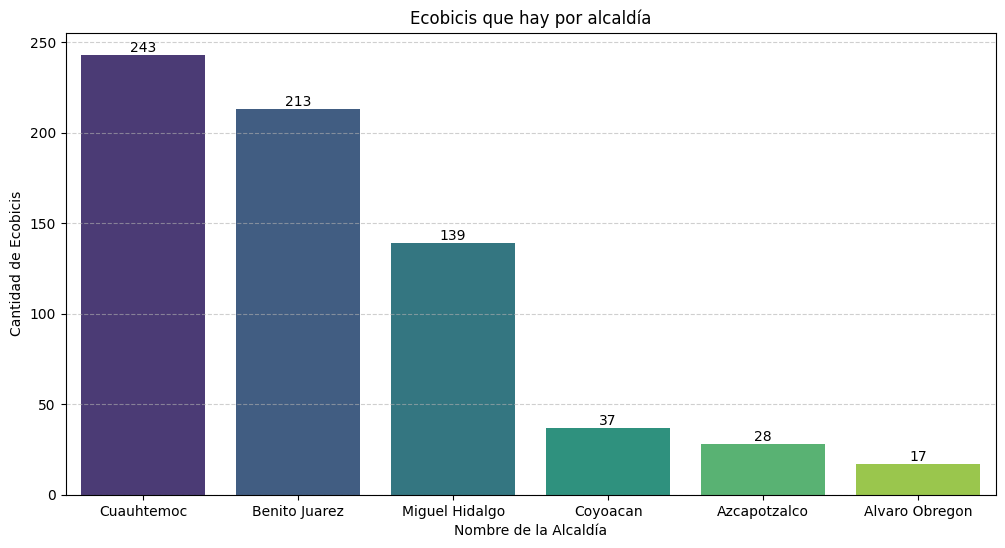

In [12]:
# ----- Graficamos Ecobicis que hay por alcaldía -----

# Vemos la cantidad de ecobicis por alcaldía
ecobicis_en_alcaldia = df["alcaldia"].value_counts()

# Graficamos
plt.figure(figsize=(12,6))
plt.title("Ecobicis que hay por alcaldía")
barras = sns.barplot(x=ecobicis_en_alcaldia.index,
                     y=ecobicis_en_alcaldia.values,
                     hue=ecobicis_en_alcaldia.index,
                     palette="viridis")
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='%.0f')
plt.xlabel("Nombre de la Alcaldía")
plt.ylabel("Cantidad de Ecobicis")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()

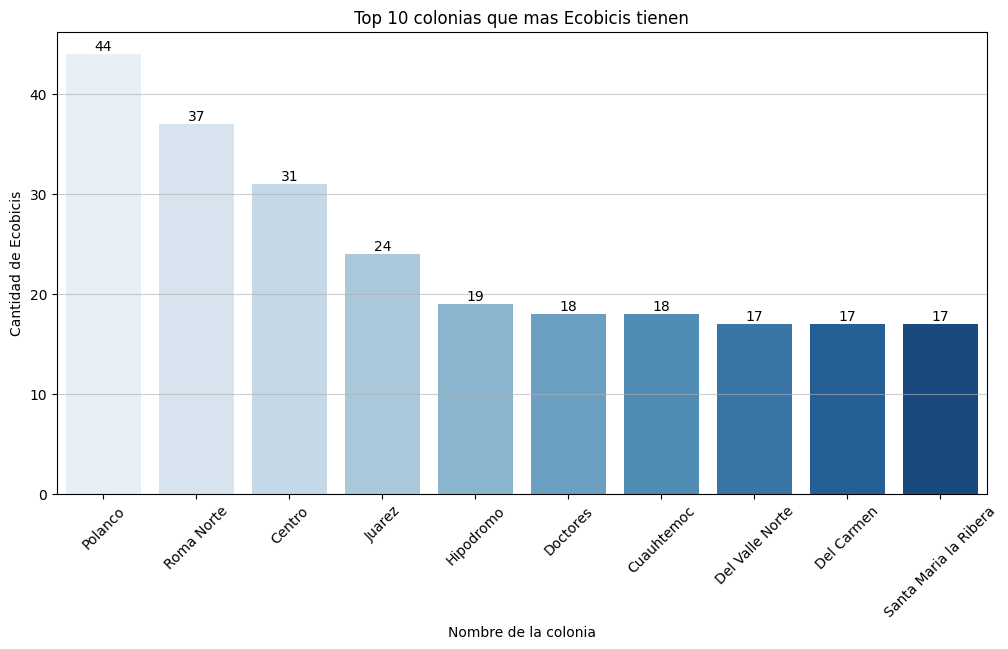

In [21]:
# ----- Graficamos las top 10 colonias que mas Ecobicis tienen -----

# Vemos el top 5 de colonias con mas Ecobicis
ecobicis_por_colonia = df.groupby("colonia")["estatus"].size().sort_values(ascending=False).head(10)

# Graficamos
plt.figure(figsize=(12,6))
plt.title("Top 10 colonias que mas Ecobicis tienen")
barras = sns.barplot(x=ecobicis_por_colonia.index,
                     y=ecobicis_por_colonia.values,
                     hue=ecobicis_por_colonia.index,
                     palette="Blues")
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='%.0f')
plt.xlabel("Nombre de la colonia")
plt.ylabel("Cantidad de Ecobicis")
plt.grid(axis="y",
         linestyle="-",
         alpha=0.6)
plt.xticks(rotation=45,
           ha="center")
plt.show()